<a href="https://colab.research.google.com/github/Keshav-Agrawal654/Keshav_23FE10CSE00810_MLlab/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (857, 30)
Training set size: 599
Test set size:     258

Confusion Matrix:
[[133  24]
 [ 22  79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       157
           1       0.77      0.78      0.77       101

    accuracy                           0.82       258
   macro avg       0.81      0.81      0.81       258
weighted avg       0.82      0.82      0.82       258

Accuracy: 0.8217
ROC-AUC: 0.8229


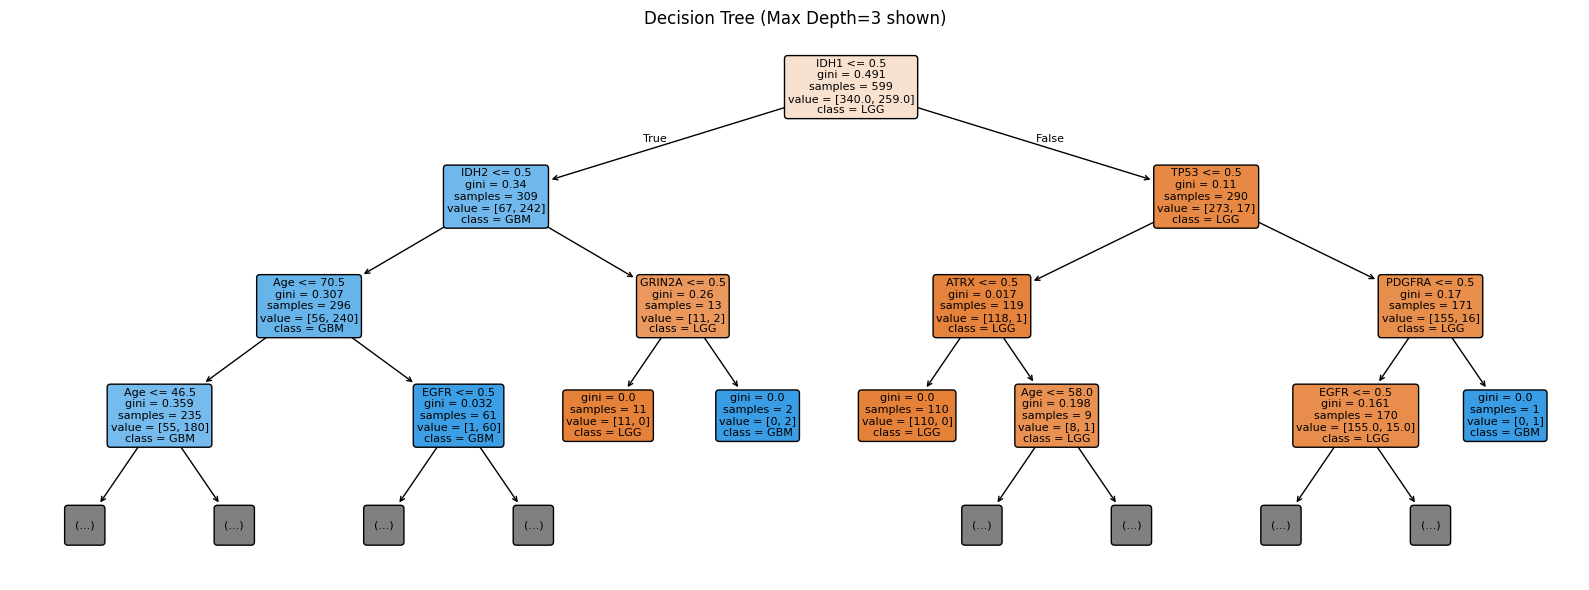

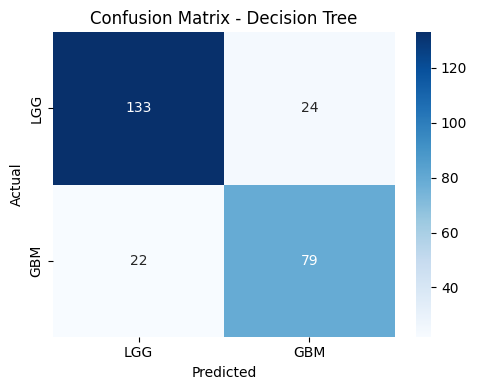

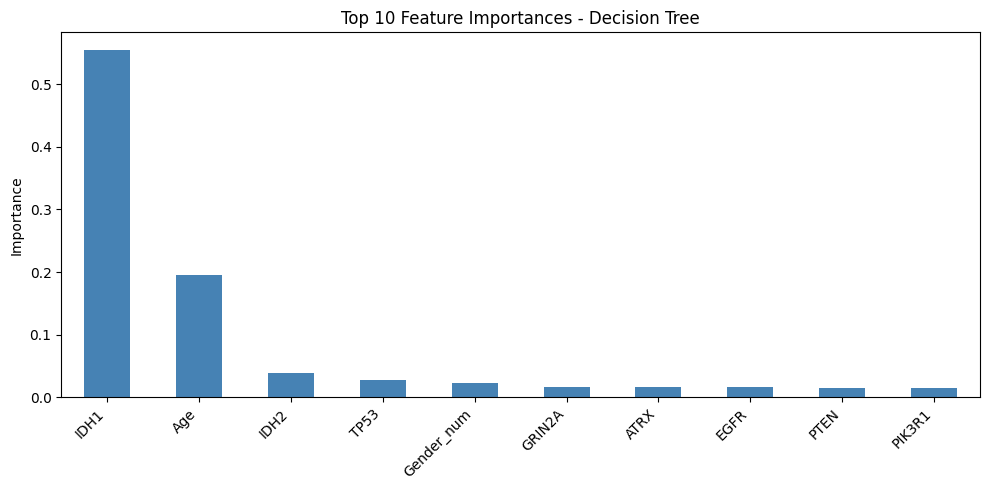


Confusion Matrix (Pruned DT, max_depth=5):
[[126  31]
 [ 11  90]]

Classification Report (Pruned DT):
              precision    recall  f1-score   support

           0       0.92      0.80      0.86       157
           1       0.74      0.89      0.81       101

    accuracy                           0.84       258
   macro avg       0.83      0.85      0.83       258
weighted avg       0.85      0.84      0.84       258

Accuracy: 0.8372
ROC-AUC: 0.8932


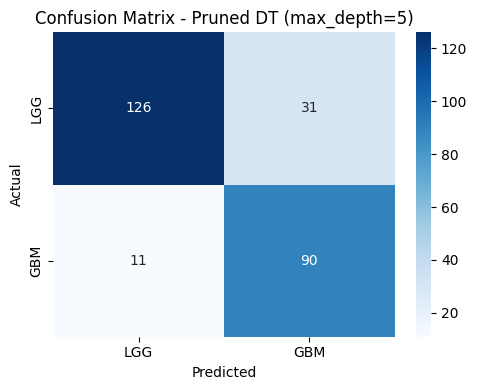

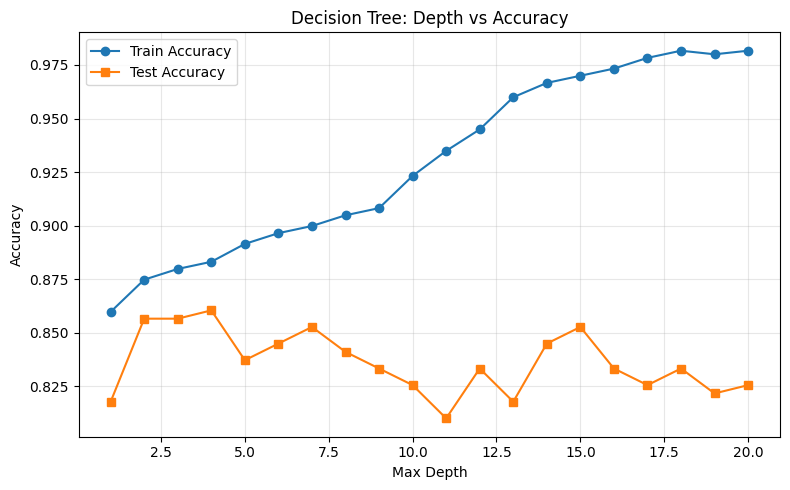

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# ── Helper & constants ──────────────────────────────────────────
def parse_age(s):
    m = re.search(r'(\d+)\s*years?', str(s))
    return int(m.group(1)) if m else None

mut_cols = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
            'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
            'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# ── Load & preprocess ───────────────────────────────────────────
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
df['Age'] = df['Age_at_diagnosis'].apply(parse_age)
for c in mut_cols:
    df[c] = (df[c] == 'MUTATED').astype(int)
df['Gender_num'] = (df['Gender'] == 'Male').astype(int)
df['target'] = (df['Grade'] == 'GBM').astype(int)
df = df.dropna(subset=['Age'])
print(f"Dataset shape: {df.shape}")

# ── Train / Test Split ──────────────────────────────────────────
feature_cols = mut_cols + ['Age', 'Gender_num']
X = df[feature_cols]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

# ── Default Decision Tree ───────────────────────────────────────
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
preds = dt.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))
print("Accuracy:", round(accuracy_score(y_test, preds), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]), 4))

# ── Tree Visualization (depth 3) ────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(dt, feature_names=feature_cols, class_names=['LGG','GBM'],
          max_depth=3, filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('Decision Tree (Max Depth=3 shown)')
plt.tight_layout()
plt.show()

# ── Confusion Matrix Heatmap ────────────────────────────────────
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d',
            cmap='Blues', xticklabels=['LGG','GBM'], yticklabels=['LGG','GBM'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Feature Importance ──────────────────────────────────────────
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(10).plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Top 10 Feature Importances - Decision Tree')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Pruned Tree (max_depth=5) ───────────────────────────────────
dt_pruned = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_pruned.fit(X_train, y_train)
preds_pruned = dt_pruned.predict(X_test)

print("\nConfusion Matrix (Pruned DT, max_depth=5):")
print(confusion_matrix(y_test, preds_pruned))
print("\nClassification Report (Pruned DT):")
print(classification_report(y_test, preds_pruned))
print("Accuracy:", round(accuracy_score(y_test, preds_pruned), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, dt_pruned.predict_proba(X_test)[:,1]), 4))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, preds_pruned), annot=True, fmt='d',
            cmap='Blues', xticklabels=['LGG','GBM'], yticklabels=['LGG','GBM'])
plt.title('Confusion Matrix - Pruned DT (max_depth=5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── Depth vs Accuracy ───────────────────────────────────────────
depths = range(1, 21)
train_accs, test_accs = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, label='Train Accuracy', marker='o')
plt.plot(depths, test_accs, label='Test Accuracy', marker='s')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Depth vs Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()